In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [ ]:
# Load the breast cancer dataset from sklearn
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first 5 rows of the dataset
print(df.head())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

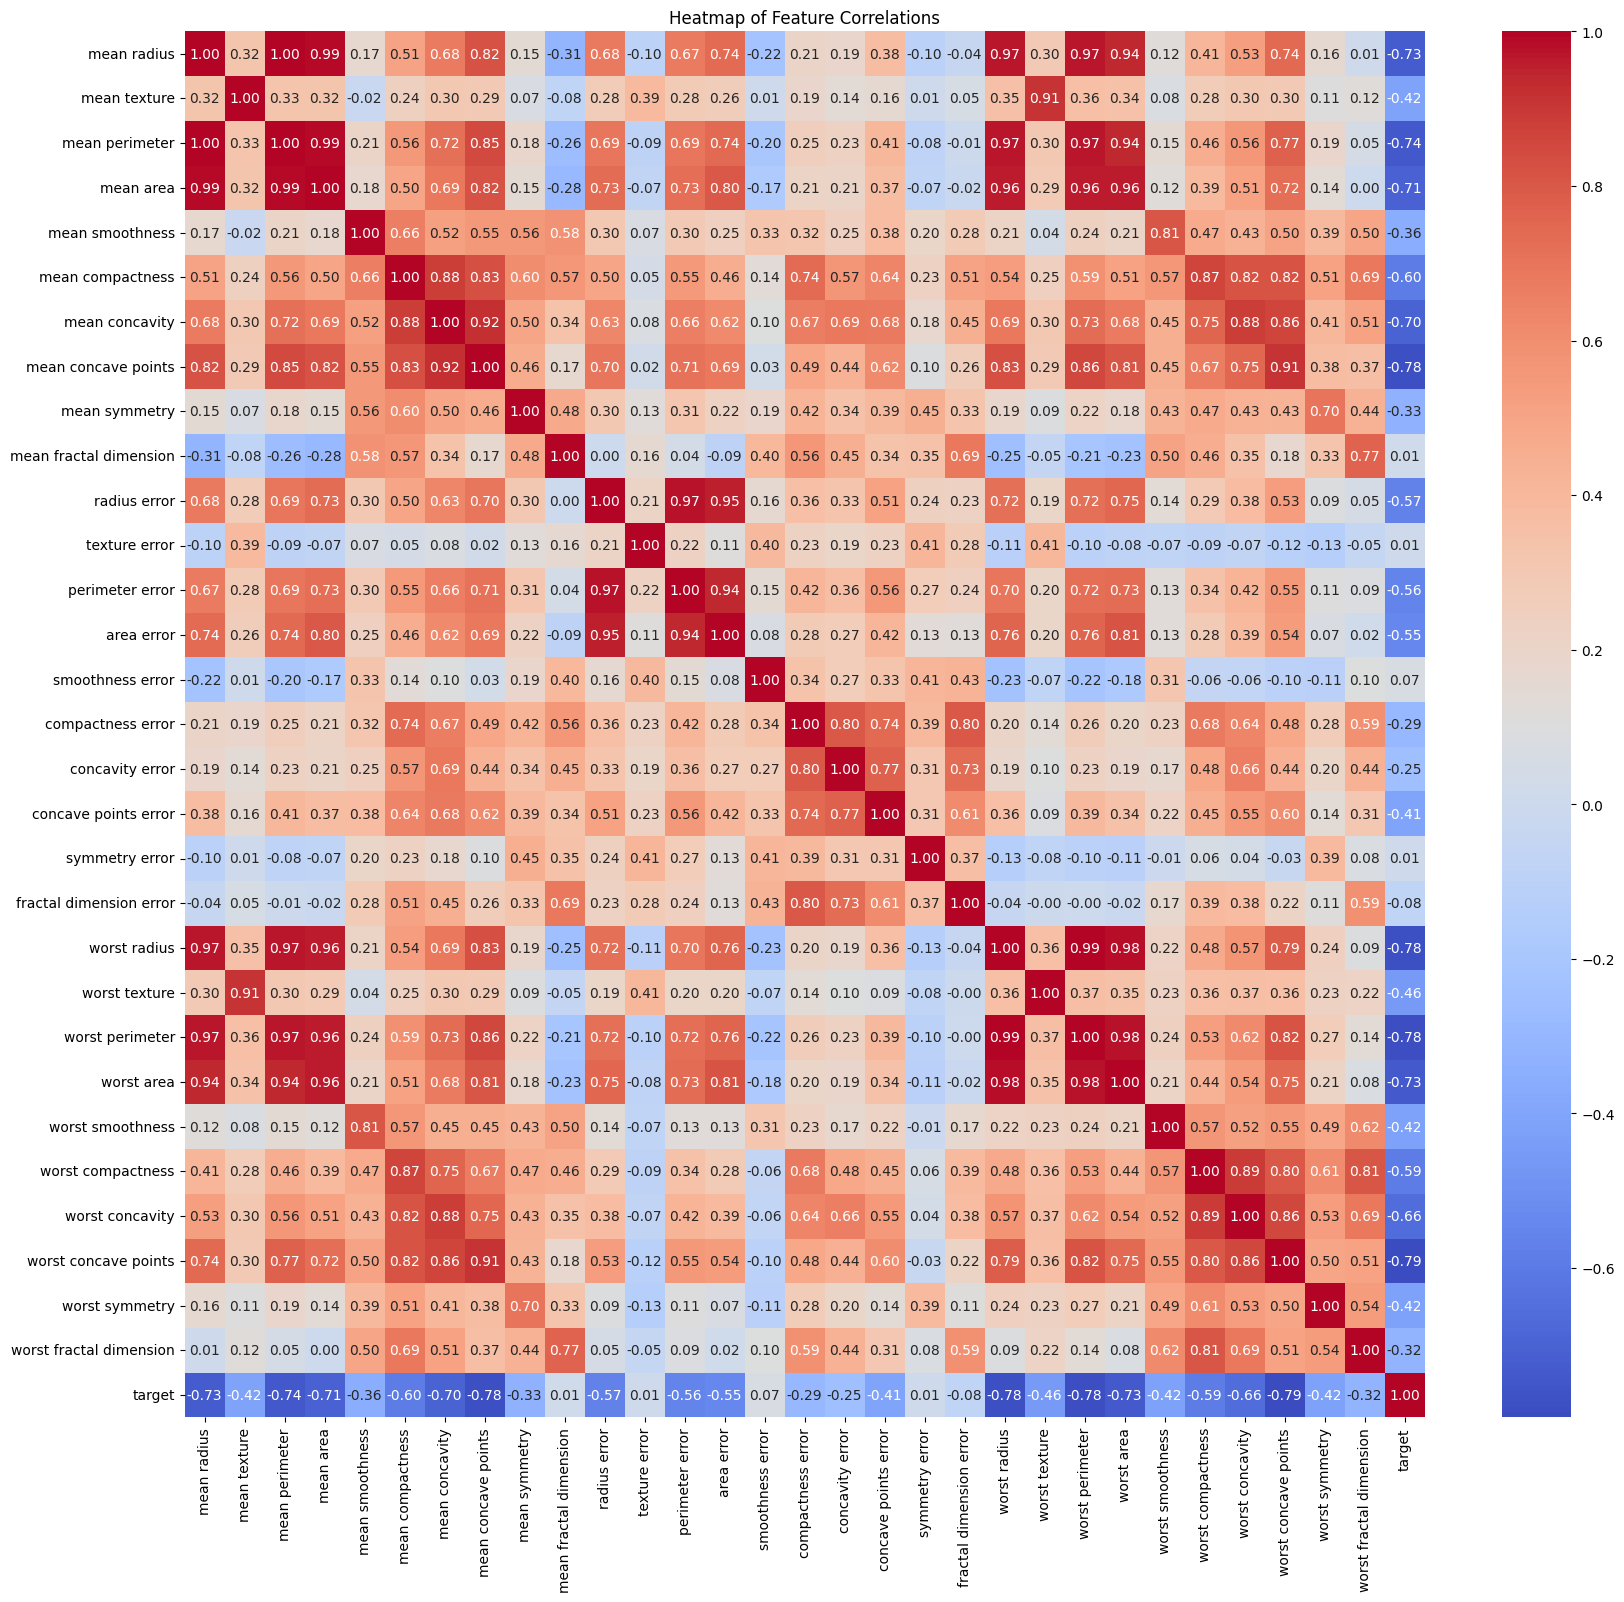

In [ ]:
# Display correlation heatmap
plt.figure(figsize=(20, 18))
correlation_matrix = df.corr()  # Calculate the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Heatmap of Feature Correlations")
plt.show()


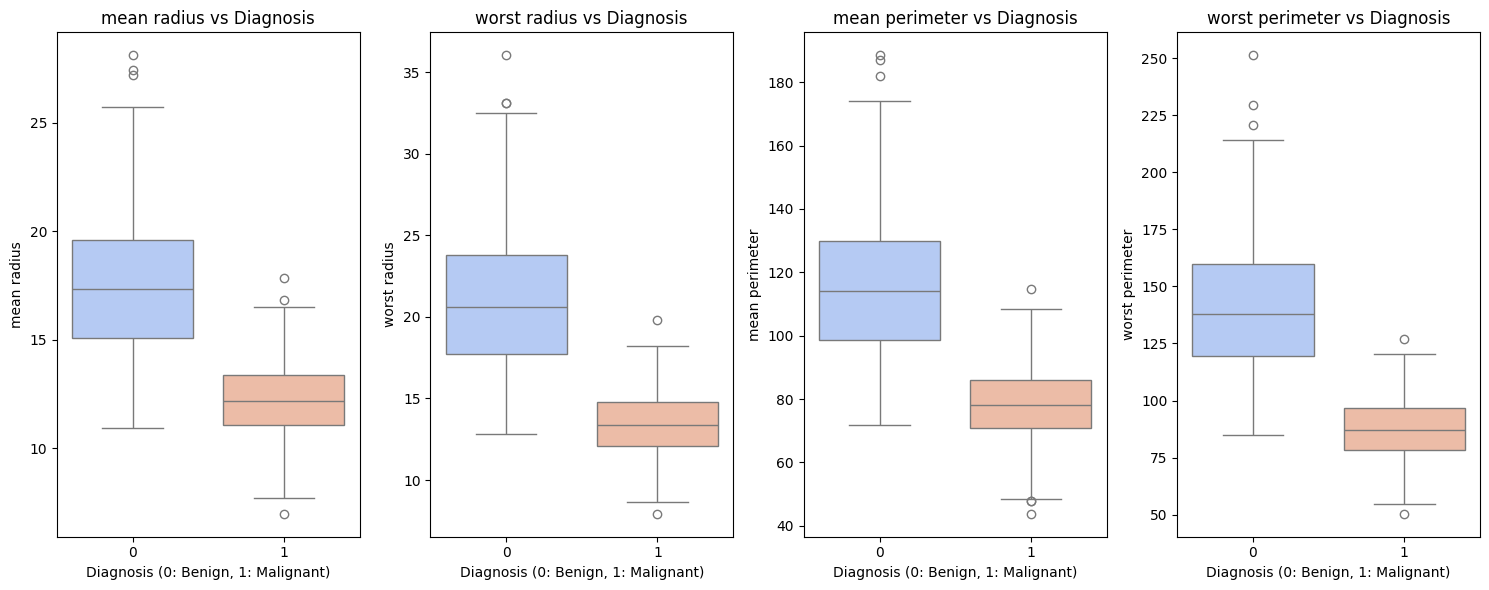

In [ ]:
# Visualize correlation of radius features with diagnosis (target)
plt.figure(figsize=(15, 6))

# Create a list of radius-related features
radius_features = ['mean radius', 'worst radius', 'mean perimeter', 'worst perimeter']

# Create a subplot for each feature
for i, feature in enumerate(radius_features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(x='target', y=feature, data=df, hue='target', palette="coolwarm", legend=False)
    plt.title(f'{feature} vs Diagnosis')
    plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
    plt.ylabel(f'{feature}')

plt.tight_layout()
plt.show()

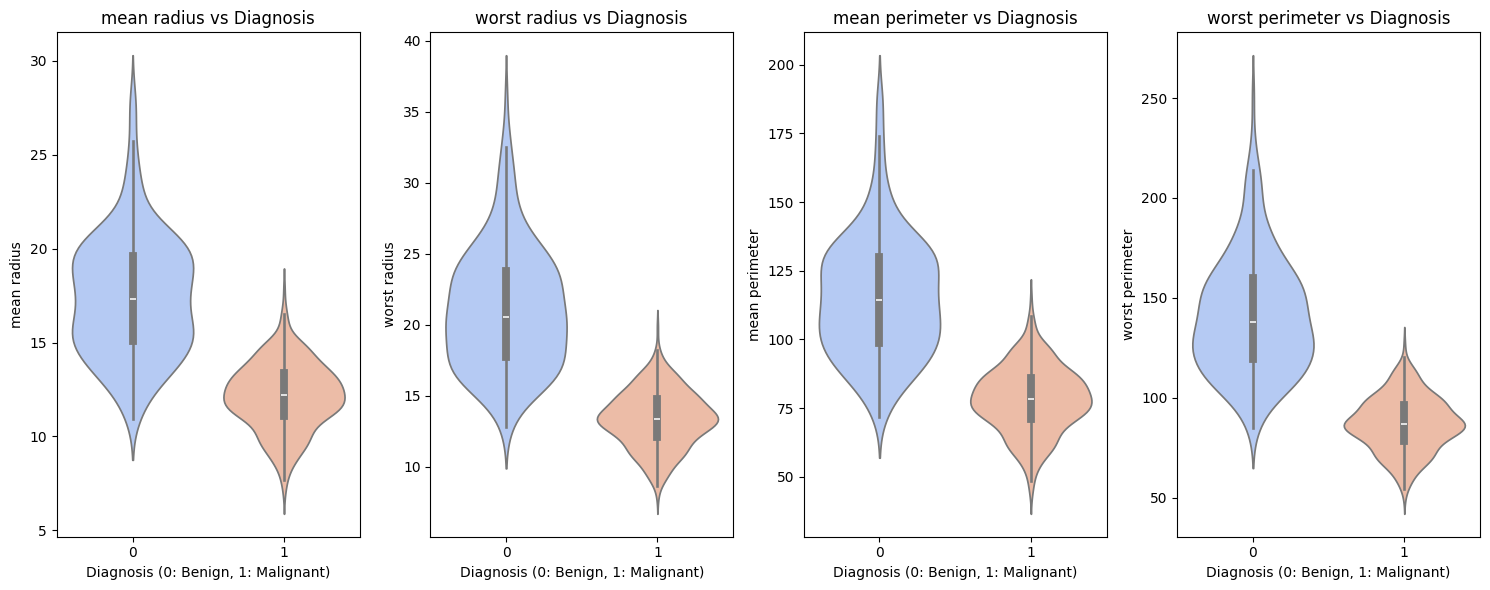

In [ ]:
# Visualize correlation of radius features with diagnosis (target)
plt.figure(figsize=(15, 6))

# Create a list of radius-related features
radius_features = ['mean radius', 'worst radius', 'mean perimeter', 'worst perimeter']

# Create a subplot for each feature
for i, feature in enumerate(radius_features, 1):
    plt.subplot(1, 4, i)
    sns.violinplot(x='target', y=feature, data=df, hue='target', palette="coolwarm", legend=False)
    plt.title(f'{feature} vs Diagnosis')
    plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
    plt.ylabel(f'{feature}')

plt.tight_layout()
plt.show()

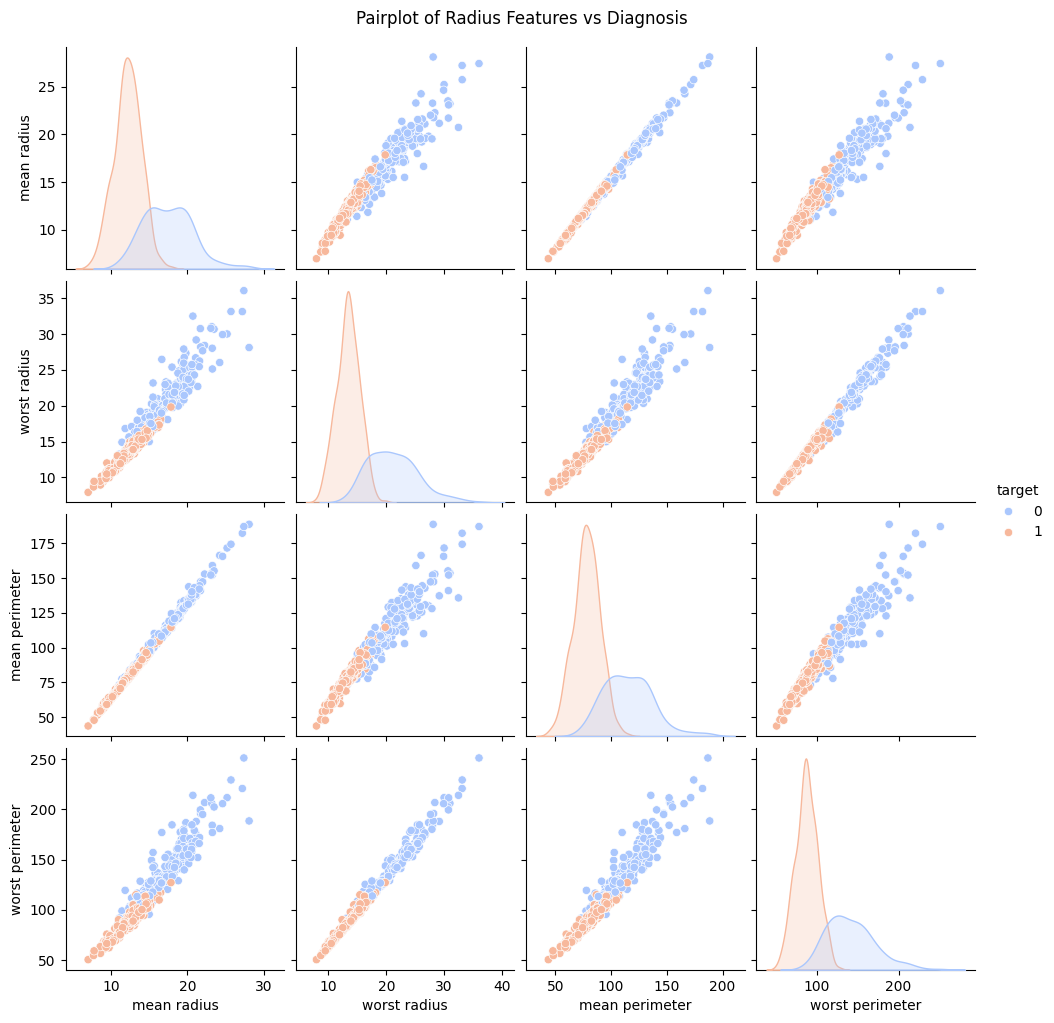

In [ ]:
# Select the radius-related features and the target (diagnosis)
radius_features = ['mean radius', 'worst radius', 'mean perimeter', 'worst perimeter', 'target']

# Create a DataFrame with only the selected radius features and target
df_radius = df[radius_features]

# Plot pairplot of radius features vs diagnosis (target)
sns.pairplot(df_radius, hue='target', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot of Radius Features vs Diagnosis', y=1.02)
plt.show()

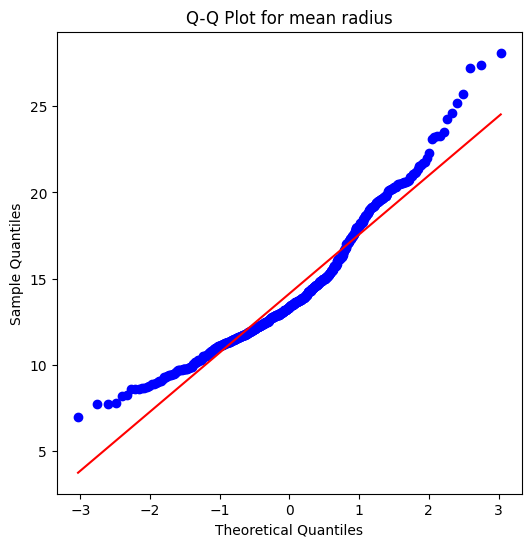

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset from sklearn
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Select a feature to check for normality (e.g., 'mean radius')
feature = 'mean radius'

#HW display Q-Q plot for all features :  worst radius', 'mean perimeter', 'worst perimeter', 'target'
# Create a Q-Q plot to check for normality of 'mean radius'
plt.figure(figsize=(6, 6))
stats.probplot(df[feature], dist="norm", plot=plt)
plt.title(f"Q-Q Plot for {feature}")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()


In [ ]:
# Filter out features that have correlation > 0.5 with the target variable
correlation_with_target = correlation_matrix['target'].abs()
high_corr_features = correlation_with_target[correlation_with_target > 0.5].index.tolist()

# Remove the target from the feature list
high_corr_features.remove('target')

print(f"Features with correlation > 0.5 with target: {high_corr_features}")

# Create the filtered feature set based on the correlation threshold
X_filtered = df[high_corr_features]
y = df['target']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Build a pipeline for preprocessing (handling missing values and scaling)
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Apply the preprocessing pipeline to the training and testing sets
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Create and train the Logistic Regression model
model = LogisticRegression() ##Hw try to apply L2 regularization, select the best solver
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

#HW ADD more matrices, recall, f-measure, sensitivity, specificity, ROC,
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred, target_names=data.target_names)
print("\nClassification Report:")
print(class_report)

Features with correlation > 0.5 with target: ['mean radius', 'mean perimeter', 'mean area', 'mean compactness', 'mean concavity', 'mean concave points', 'radius error', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area', 'worst compactness', 'worst concavity', 'worst concave points']
Accuracy: 96.49%

Confusion Matrix:
[[41  2]
 [ 2 69]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        43
      benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# Split the dataset into features (X) and target (y)  #OPTIONAL THIS DOES NOT SELECT THE FEATURES WITH HIGH CORRELATION
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a pipeline for preprocessing (handling missing values and scaling)
# Step 1: Handle missing values using SimpleImputer (mean strategy)
# Step 2: Standardize the feature values using StandardScaler
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Apply the preprocessing pipeline to the training and testing sets
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Create and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)
#HOME WORK - apply regularization and try to improve the model accuarcy
# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred, target_names=data.target_names)
print("\nClassification Report:")
print(class_report)


Accuracy: 97.37%

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Data after outlier removal:
       mean radius  worst radius  mean perimeter  worst perimeter      target
count   532.000000    532.000000      532.000000       532.000000  532.000000
mean     13.591182     15.474641       88.200338       101.607387    0.671053
std       2.896832      3.826625       19.753192        26.210605    0.470273
min       6.981000      7.930000       43.790000        50.410000    0.000000
25%      11.600000     12.840000       74.337500        83.442500    0.000000
50%      13.110000     14.645000       84.645000        95.660000    1.000000
75%      15.065000     17.407500       98.325000       115.975000    1.000000
max      21.100000     25.700000      138.100000       168.200000    1.000000


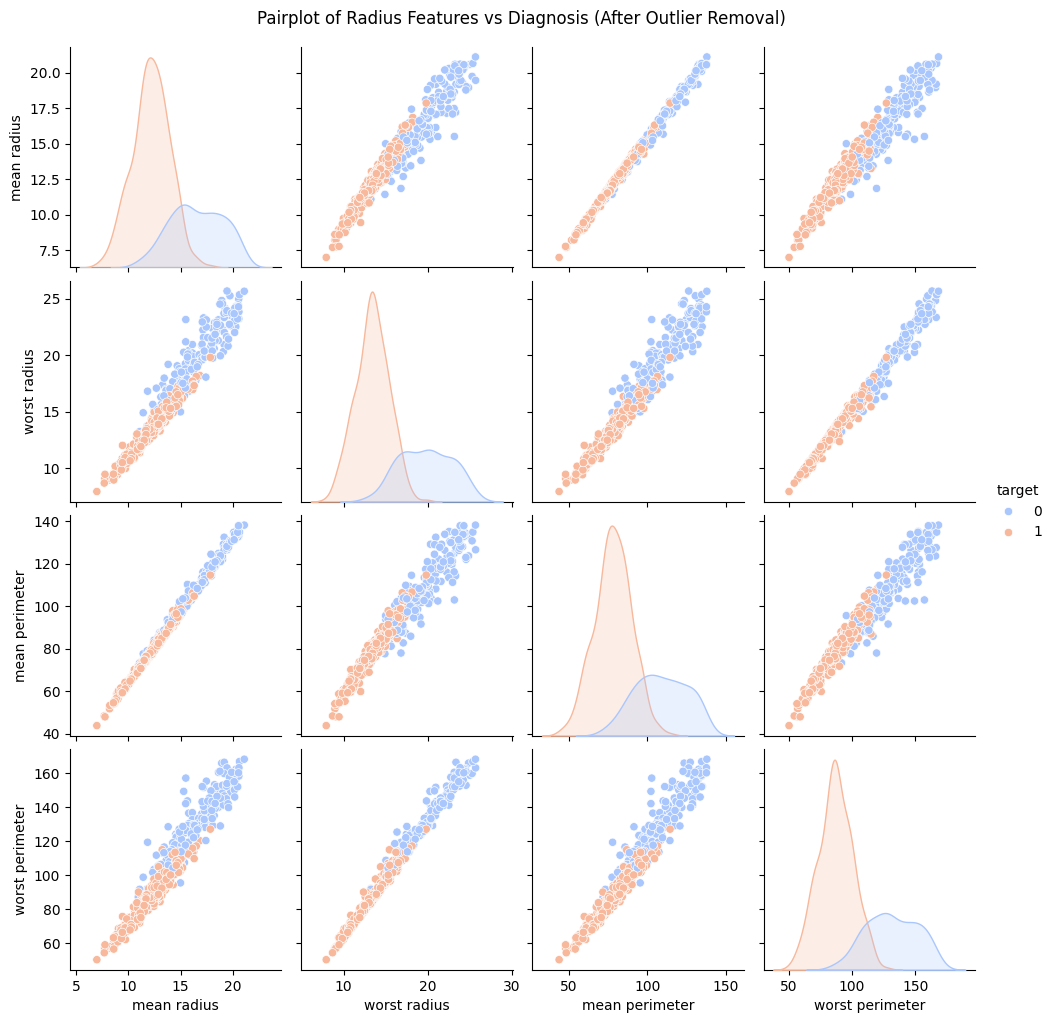

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset from sklearn
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Select the radius-related features and the target (diagnosis)
radius_features = ['mean radius', 'worst radius', 'mean perimeter', 'worst perimeter', 'target']
df_radius = df[radius_features]

# Outlier detection and removal using the IQR method
def remove_outliers(df, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    # Calculate the IQR
    IQR = Q3 - Q1
    # Define bounds for outliers (1.5 * IQR rule)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Return a dataframe with outliers removed
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply outlier removal to each of the selected radius features
for feature in radius_features[:-1]:  # Exclude 'target' column
    df_radius = remove_outliers(df_radius, feature)

print(f"Data after outlier removal:\n{df_radius.describe()}")

# Plot pairplot of radius features vs diagnosis (target) after removing outliers
sns.pairplot(df_radius, hue='target', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot of Radius Features vs Diagnosis (After Outlier Removal)', y=1.02)
plt.show()

#Home work
# Fit the logistic  regression model and check the model accuracy.